In [11]:
import pandas as pd

df = pd.read_csv("../data/student_data.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
df.shape 

(1000, 8)

### Dataset Shape

- Number of rows: 1000  
- Number of columns: 8  

This dataset contains 1000 student records with 8 features related to demographics and exam scores.


In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### Dataset Information

- The dataset contains **1000 student records** and **8 columns**.
- There are **5 categorical features**:
  - gender  
  - race/ethnicity  
  - parental level of education  
  - lunch  
  - test preparation course
- There are **3 numerical features**:
  - math score  
  - reading score  
  - writing score
- All columns have **1000 non-null values**, indicating **no missing data**.
- Score-related columns are stored as integers (`int64`), which is appropriate for numerical analysis.


In [14]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Summary Statistics

- The dataset contains exam scores for **1000 students** across three subjects: math, reading, and writing.
- The **average scores** are:
  - Math: ~66
  - Reading: ~69
  - Writing: ~68
- Median scores for all three subjects are close to their mean values, indicating **balanced distributions**.
- Scores range from **0 to 100**, confirming valid and standardized exam results.
- The standard deviation across subjects (~14–15) suggests **moderate variation** in student performance.


In [15]:
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

The dataset does not contain missing values.

In [16]:
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df[["math score", "reading score", "writing score", "average_score"]].head()


,math score,reading score,writing score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


### Feature Engineering

An `average_score` feature was created to represent overall student performance.
This combines math, reading, and writing scores into a single metric,
making it easier to analyze overall trends and comparisons.


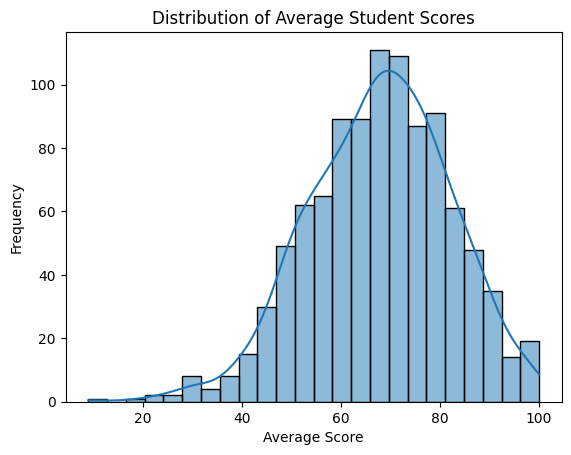

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["average_score"], kde=True)
plt.title("Distribution of Average Student Scores")
plt.xlabel("Average Score")
plt.ylabel("Frequency")
plt.show()


### Distribution of Student Performance

The distribution of average scores appears approximately normal.
Most students score in the mid-range, with fewer students achieving
very low or very high scores.


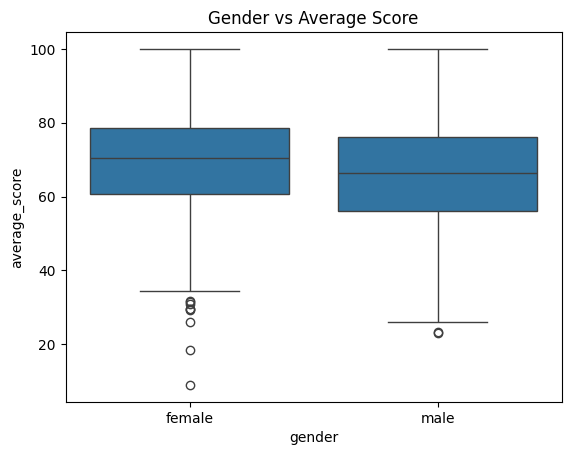

In [18]:
sns.boxplot(x="gender", y="average_score", data=df)
plt.title("Gender vs Average Score")
plt.show()


### Gender and Student Performance

Female students show a slightly higher median average score compared
to male students, indicating a small performance difference.


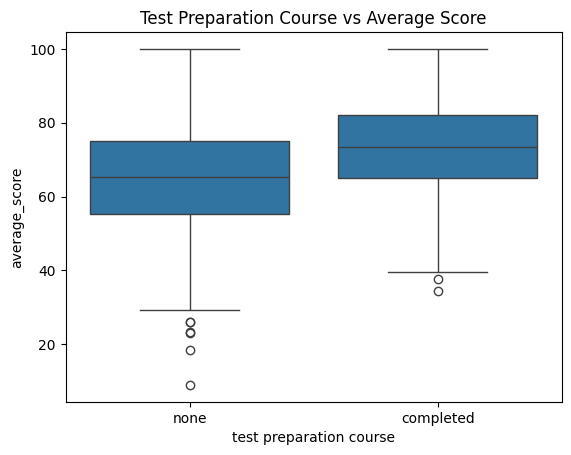

In [19]:
sns.boxplot(
    x="test preparation course",
    y="average_score",
    data=df
)
plt.title("Test Preparation Course vs Average Score")
plt.show()


### Impact of Test Preparation Course

Students who completed the test preparation course tend to have
higher average scores compared to those who did not.


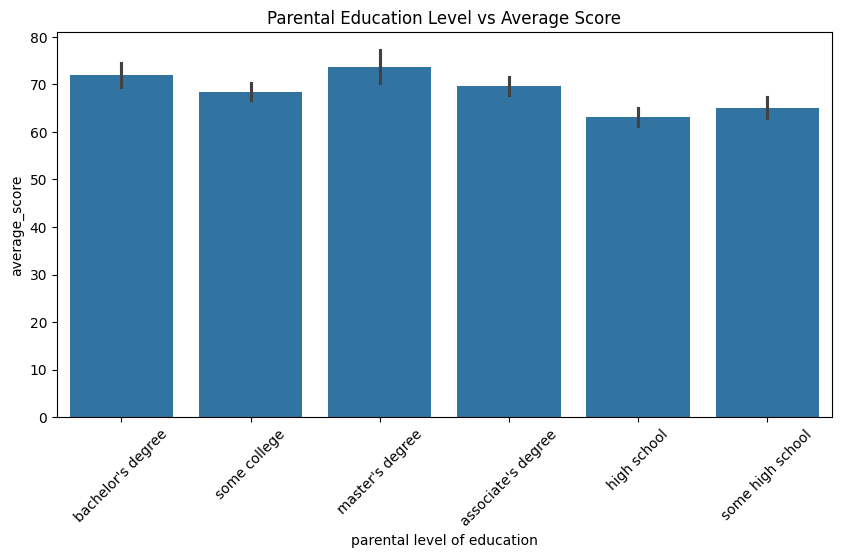

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(
    x="parental level of education",
    y="average_score",
    data=df
)
plt.xticks(rotation=45)
plt.title("Parental Education Level vs Average Score")
plt.show()


### Parental Education and Student Performance

Student performance generally improves as parental education level increases,
suggesting a positive relationship between the two.


## 📌 Key Insights

- Student performance follows an approximately normal distribution.
- Test preparation courses have a positive impact on average scores.
- Higher parental education levels are associated with better performance.
- Gender-based differences are observable in overall student scores.
